# Training Results Comparison Report

This notebook compares training results across different segmentation experiments:

- **E1**: Baseline comparison (E1-no vs E1-augmentation)
- **E2**: Architecture comparison (E1-augmentation vs E2-2.5D vs E2-3D)
- **E3**: Loss function comparison (E2-2.5D vs E3-CE-Dice vs E3-Dice vs E3-Focal)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.facecolor'] = 'white'

# Publication-appropriate sizing for a 174 mm wide figure (~6.85 in).
plt.rcParams.update({
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.titleweight': 'bold',
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'legend.title_fontsize': 7,
    'lines.linewidth': 1.0,
    'lines.markersize': 4,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'grid.linewidth': 0.4,
    'patch.linewidth': 0.6,
})

base_dir = Path("/home/s222440401/project/segmentation_experiment")

# ---- Publication figure export setup ----
# Single-column journal width = 84 mm, double-column = 174 mm.
MM_PER_INCH = 25.4
WIDTH_SINGLE_IN = 84.0 / MM_PER_INCH   # ~3.31 in
WIDTH_DOUBLE_IN = 174.0 / MM_PER_INCH  # ~6.85 in

FIG_DIR = Path("/home/s222440401/project/segmentation_experiment/report/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name, fig=None, dpi=600):
    """Save current (or given) figure as PNG and PDF at >= 600 DPI."""
    if fig is None:
        fig = plt.gcf()
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=dpi, bbox_inches="tight", facecolor="white")


In [2]:
#!pip install seaborn

## 1. Load Training Data


In [3]:
# Define experiment directories
experiments = {
    'E1-no': base_dir / 'E1-no',
    'E1-augmentation': base_dir / 'E1-augmentation',
    'E2-2.5D': base_dir / 'E2-2.5D',
    'E2-3D': base_dir / 'E2-3D',
    'E3-CE-Dice': base_dir / 'E3-CE-Dice',
    'E3-Dice': base_dir / 'E3-Dice',
    'E3-Focal': base_dir / 'E3-Focal'
}

# Load training efficiency data
training_data = {}
for exp_name, exp_dir in experiments.items():
    eff_file = exp_dir / 'training_reports' / 'training_efficiency.csv'
    if eff_file.exists():
        df = pd.read_csv(eff_file)
        df['experiment'] = exp_name
        training_data[exp_name] = df
        print(f"Loaded {exp_name}: {len(df)} runs")

# Combine all training data
all_training = pd.concat(training_data.values(), ignore_index=True)
print(f"\nTotal training runs: {len(all_training)}")


Loaded E1-no: 5 runs
Loaded E1-augmentation: 5 runs
Loaded E2-2.5D: 5 runs
Loaded E2-3D: 5 runs
Loaded E3-CE-Dice: 5 runs
Loaded E3-Dice: 5 runs
Loaded E3-Focal: 5 runs

Total training runs: 35


In [4]:
# Load convergence data where available
convergence_data = {}
for exp_name, exp_dir in experiments.items():
    conv_file = exp_dir / 'training_reports' / 'convergence.csv'
    if conv_file.exists():
        df = pd.read_csv(conv_file)
        df['experiment'] = exp_name
        convergence_data[exp_name] = df

if convergence_data:
    all_convergence = pd.concat(convergence_data.values(), ignore_index=True)
    print(f"Convergence data available for: {list(convergence_data.keys())}")
else:
    all_convergence = pd.DataFrame()
    print("No convergence data available")


Convergence data available for: ['E1-no', 'E1-augmentation', 'E2-2.5D', 'E2-3D']


In [5]:
# Load inference data where available
inference_data = {}
for exp_name, exp_dir in experiments.items():
    inf_file = exp_dir / 'training_reports' / 'inference.csv'
    if inf_file.exists():
        df = pd.read_csv(inf_file)
        df['experiment'] = exp_name
        inference_data[exp_name] = df

if inference_data:
    all_inference = pd.concat(inference_data.values(), ignore_index=True)
    print(f"Inference data available for: {list(inference_data.keys())}")
else:
    all_inference = pd.DataFrame()
    print("No inference data available")


Inference data available for: ['E1-no', 'E1-augmentation', 'E2-2.5D', 'E2-3D', 'E3-CE-Dice', 'E3-Dice', 'E3-Focal']


## 2. E1: Baseline Comparison (No Augmentation vs Augmentation)


In [6]:
# Filter E1 experiments
e1_experiments = ['E1-no', 'E1-augmentation']
e1_data = all_training[all_training['experiment'].isin(e1_experiments)].copy()

# Calculate summary statistics
e1_summary = e1_data.groupby('experiment').agg({
    'Total Training Time (hours)': ['mean', 'std', 'min', 'max'],
    'Average Epoch Time(s)': ['mean', 'std'],
    'Average RAM (GB)': ['mean', 'std'],
    'Average GPU Memory (GB)': ['mean', 'std'],
    'CO2 Emissions (kg)': ['mean', 'std', 'sum']
}).round(3)

print("E1 Training Summary Statistics:")
print(e1_summary)


E1 Training Summary Statistics:
                Total Training Time (hours)                         \
                                       mean    std     min     max   
experiment                                                           
E1-augmentation                      16.354  0.274  16.112  16.750   
E1-no                                15.517  0.756  14.565  16.675   

                Average Epoch Time(s)          Average RAM (GB)         \
                                 mean      std             mean    std   
experiment                                                               
E1-augmentation              2943.707   49.388            1.245  0.009   
E1-no                        2793.005  136.158            1.229  0.048   

                Average GPU Memory (GB)      CO2 Emissions (kg)                
                                   mean  std               mean    std    sum  
experiment                                                                     
E1-aug

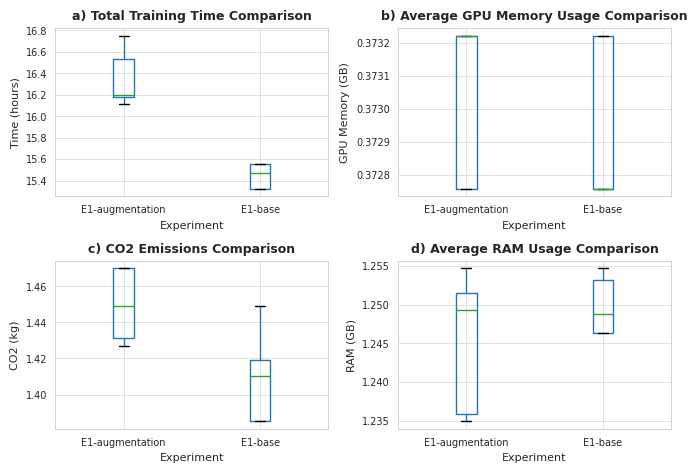

In [7]:
# Visualization for E1
# Create a copy with renamed experiments for display
e1_data_display = e1_data.copy()
e1_data_display['experiment'] = e1_data_display['experiment'].replace({'E1-no': 'E1-base'})

fig, axes = plt.subplots(2, 2, figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 10/14))

# Training time comparison
ax1 = axes[0, 0]
e1_data_display.boxplot(column='Total Training Time (hours)', by='experiment', ax=ax1, showfliers=False)
ax1.set_title('a) Total Training Time Comparison')
ax1.set_xlabel('Experiment')
ax1.set_ylabel('Time (hours)')
plt.suptitle('')

# GPU Memory comparison
ax2 = axes[0, 1]
e1_data_display.boxplot(column='Average GPU Memory (GB)', by='experiment', ax=ax2, showfliers=False)
ax2.set_title('b) Average GPU Memory Usage Comparison')
ax2.set_xlabel('Experiment')
ax2.set_ylabel('GPU Memory (GB)')
plt.suptitle('')

# CO2 emissions comparison
ax3 = axes[1, 0]
e1_data_display.boxplot(column='CO2 Emissions (kg)', by='experiment', ax=ax3, showfliers=False)
ax3.set_title('c) CO2 Emissions Comparison')
ax3.set_xlabel('Experiment')
ax3.set_ylabel('CO2 (kg)')
plt.suptitle('')

# RAM usage comparison
ax4 = axes[1, 1]
e1_data_display.boxplot(column='Average RAM (GB)', by='experiment', ax=ax4, showfliers=False)
ax4.set_title('d) Average RAM Usage Comparison')
ax4.set_xlabel('Experiment')
ax4.set_ylabel('RAM (GB)')
plt.suptitle('')

plt.tight_layout()
save_fig('e1_training_resources')
plt.show()



E1 Convergence Statistics:
                Convergence Epoch               Total Training Time (hours)  \
                             mean   std min max                        mean   
experiment                                                                    
E1-augmentation              23.0  1.58  21  25                       18.84   
E1-no                        18.0  0.82  17  19                       13.95   

                       
                  std  
experiment             
E1-augmentation  1.04  
E1-no            0.93  


<Figure size 685.039x428.15 with 0 Axes>

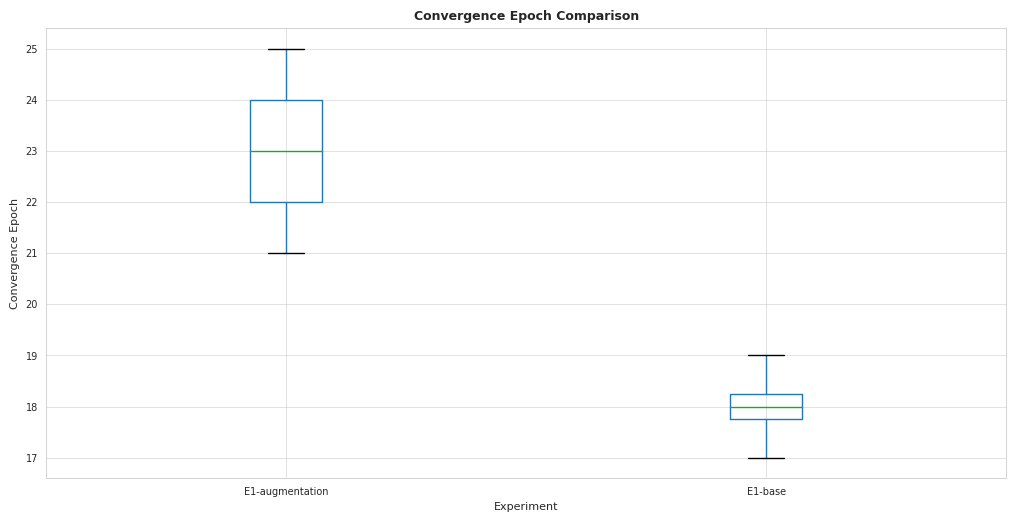

In [8]:
# Convergence comparison for E1
if 'E1-no' in convergence_data and 'E1-augmentation' in convergence_data:
    e1_conv = all_convergence[all_convergence['experiment'].isin(e1_experiments)].copy()
    
    if not e1_conv.empty:
        print("\nE1 Convergence Statistics:")
        conv_summary = e1_conv.groupby('experiment').agg({
            'Convergence Epoch': ['mean', 'std', 'min', 'max'],
            'Total Training Time (hours)': ['mean', 'std']
        }).round(2)
        print(conv_summary)
        
        # Plot convergence epochs - create display copy with renamed experiments
        e1_conv_display = e1_conv.copy()
        e1_conv_display['experiment'] = e1_conv_display['experiment'].replace({'E1-no': 'E1-base'})
        plt.figure(figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 5/8))
        e1_conv_display.boxplot(column='Convergence Epoch', by='experiment', showfliers=False)
        plt.title('Convergence Epoch Comparison')
        plt.xlabel('Experiment')
        plt.ylabel('Convergence Epoch')
        plt.suptitle('')
        save_fig('e1_convergence_epoch')
        plt.show()
else:
    print("Convergence data not available for E1 experiments")


## 3. E2: Architecture Comparison (2D Augmentation vs 2.5D vs 3D)


In [9]:
# Filter E2 experiments
e2_experiments = ['E1-augmentation', 'E2-2.5D', 'E2-3D']
e2_data = all_training[all_training['experiment'].isin(e2_experiments)].copy()

# Calculate summary statistics
e2_summary = e2_data.groupby('experiment').agg({
    'Total Training Time (hours)': ['mean', 'std', 'min', 'max'],
    'Average Epoch Time(s)': ['mean', 'std'],
    'Average RAM (GB)': ['mean', 'std'],
    'Average GPU Memory (GB)': ['mean', 'std'],
    'CO2 Emissions (kg)': ['mean', 'std', 'sum']
}).round(3)

print("E2 Training Summary Statistics:")
print(e2_summary)


E2 Training Summary Statistics:
                Total Training Time (hours)                         \
                                       mean    std     min     max   
experiment                                                           
E1-augmentation                      16.354  0.274  16.112  16.750   
E2-2.5D                              18.629  0.167  18.412  18.821   
E2-3D                                 5.257  0.124   5.136   5.438   

                Average Epoch Time(s)         Average RAM (GB)         \
                                 mean     std             mean    std   
experiment                                                              
E1-augmentation              2943.707  49.388            1.245  0.009   
E2-2.5D                      3353.240  30.071            1.255  0.018   
E2-3D                          94.618   2.223            1.316  0.020   

                Average GPU Memory (GB)      CO2 Emissions (kg)                
                            

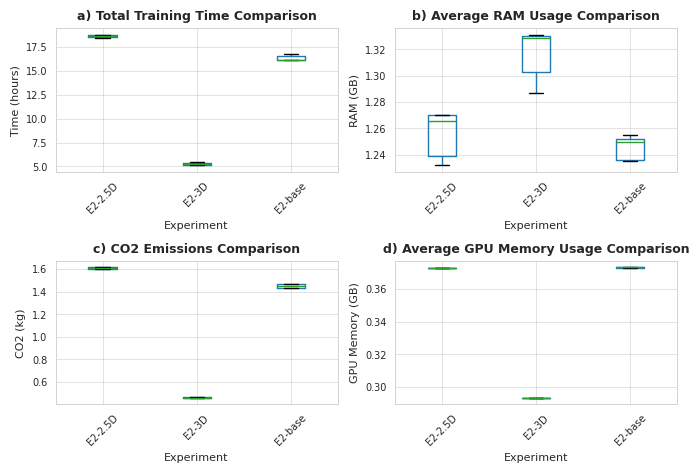

In [10]:
# Visualization for E2
# Create a copy with renamed experiments for display
e2_data_display = e2_data.copy()
e2_data_display['experiment'] = e2_data_display['experiment'].replace({'E1-augmentation': 'E2-base'})

fig, axes = plt.subplots(2, 2, figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 10/14))

# Training time comparison
ax1 = axes[0, 0]
e2_data_display.boxplot(column='Total Training Time (hours)', by='experiment', ax=ax1, showfliers=False)
ax1.set_title('a) Total Training Time Comparison')
ax1.set_xlabel('Experiment')
ax1.set_ylabel('Time (hours)')
plt.suptitle('')
ax1.tick_params(axis='x', rotation=45)

# RAM comparison
ax2 = axes[0, 1]
e2_data_display.boxplot(column='Average RAM (GB)', by='experiment', ax=ax2, showfliers=False)
ax2.set_title('b) Average RAM Usage Comparison')
ax2.set_xlabel('Experiment')
ax2.set_ylabel('RAM (GB)')
plt.suptitle('')
ax2.tick_params(axis='x', rotation=45)

# CO2 emissions comparison
ax3 = axes[1, 0]
e2_data_display.boxplot(column='CO2 Emissions (kg)', by='experiment', ax=ax3, showfliers=False)
ax3.set_title('c) CO2 Emissions Comparison')
ax3.set_xlabel('Experiment')
ax3.set_ylabel('CO2 (kg)')
plt.suptitle('')
ax3.tick_params(axis='x', rotation=45)

# GPU Memory comparison
ax4 = axes[1, 1]
e2_data_display.boxplot(column='Average GPU Memory (GB)', by='experiment', ax=ax4, showfliers=False)
ax4.set_title('d) Average GPU Memory Usage Comparison')
ax4.set_xlabel('Experiment')
ax4.set_ylabel('GPU Memory (GB)')
plt.suptitle('')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig('e2_training_resources')
plt.show()



E2 Convergence Statistics:
                Convergence Epoch               Total Training Time (hours)  \
                             mean   std min max                        mean   
experiment                                                                    
E1-augmentation              23.0  1.58  21  25                       18.84   
E2-2.5D                      14.0  1.58  12  16                       13.11   
E2-3D                        67.0  1.00  66  68                        1.78   

                       
                  std  
experiment             
E1-augmentation  1.04  
E2-2.5D          1.58  
E2-3D            0.03  


<Figure size 685.039x428.15 with 0 Axes>

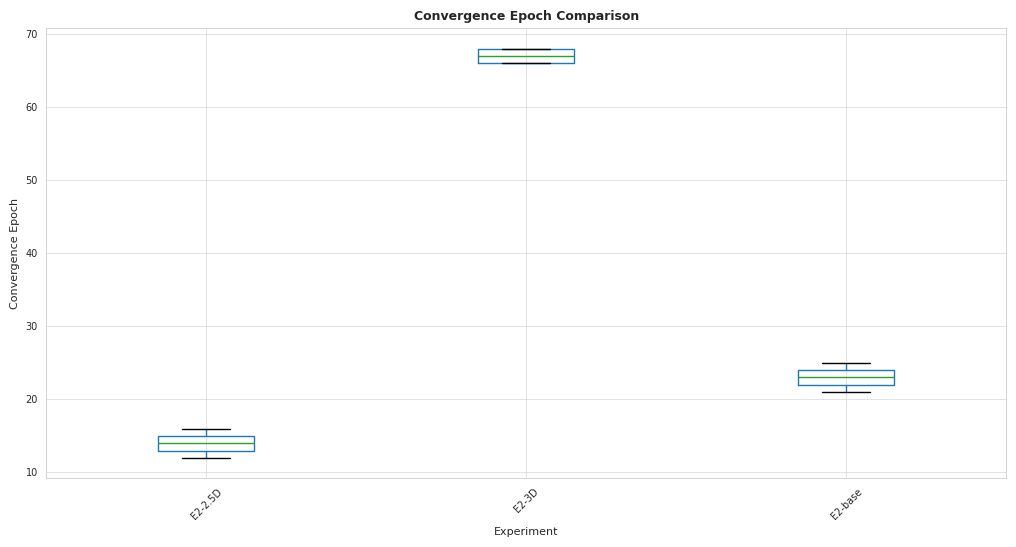

In [11]:
# Convergence comparison for E2
e2_conv_experiments = ['E1-augmentation', 'E2-2.5D', 'E2-3D']
e2_conv = all_convergence[all_convergence['experiment'].isin(e2_conv_experiments)].copy()

if not e2_conv.empty:
    print("\nE2 Convergence Statistics:")
    conv_summary = e2_conv.groupby('experiment').agg({
        'Convergence Epoch': ['mean', 'std', 'min', 'max'],
        'Total Training Time (hours)': ['mean', 'std']
    }).round(2)
    print(conv_summary)
    
    # Plot convergence epochs - create display copy with renamed experiments
    e2_conv_display = e2_conv.copy()
    e2_conv_display['experiment'] = e2_conv_display['experiment'].replace({'E1-augmentation': 'E2-base'})
    plt.figure(figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 5/8))
    e2_conv_display.boxplot(column='Convergence Epoch', by='experiment', showfliers=False)
    plt.title('Convergence Epoch Comparison')
    plt.xlabel('Experiment')
    plt.ylabel('Convergence Epoch')
    plt.suptitle('')
    plt.xticks(rotation=45)
    save_fig('e2_convergence_epoch')
    plt.show()
else:
    print("Limited convergence data available for E2 experiments")



E2 Resource Usage Until Convergence:
                Total RAM until Convergence (GB·epochs)        \
                                                   mean   std   
experiment                                                      
E1-augmentation                                   28.64  1.93   
E2-2.5D                                           17.59  2.14   
E2-3D                                             88.16  1.68   

                Total GPU until Convergence (GB·epochs)        
                                                   mean   std  
experiment                                                     
E1-augmentation                                    8.58  0.59  
E2-2.5D                                            5.22  0.59  
E2-3D                                             19.67  0.29  


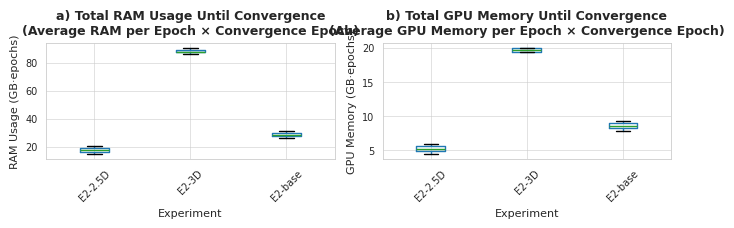

In [12]:
# Resource usage until convergence for E2
if not e2_conv.empty:
    # Merge convergence data with training data to get resource usage
    e2_resources = []
    
    for exp in e2_conv_experiments:
        conv_data = e2_conv[e2_conv['experiment'] == exp].reset_index(drop=True)
        train_data = e2_data[e2_data['experiment'] == exp].reset_index(drop=True)
        
        if not conv_data.empty and not train_data.empty:
            # Match rows by index (each row represents one run)
            min_len = min(len(conv_data), len(train_data))
            for i in range(min_len):
                e2_resources.append({
                    'experiment': exp,
                    'Run': i + 1,
                    'Convergence Epoch': conv_data.loc[i, 'Convergence Epoch'],
                    'Avg RAM per Epoch (GB)': train_data.loc[i, 'Average RAM (GB)'],
                    'Avg GPU per Epoch (GB)': train_data.loc[i, 'Average GPU Memory (GB)'],
                    'Total RAM until Convergence (GB·epochs)': train_data.loc[i, 'Average RAM (GB)'] * conv_data.loc[i, 'Convergence Epoch'],
                    'Total GPU until Convergence (GB·epochs)': train_data.loc[i, 'Average GPU Memory (GB)'] * conv_data.loc[i, 'Convergence Epoch']
                })
    
    if e2_resources:
        e2_resources_df = pd.DataFrame(e2_resources)
        
        print("\nE2 Resource Usage Until Convergence:")
        resource_summary = e2_resources_df.groupby('experiment').agg({
            'Total RAM until Convergence (GB·epochs)': ['mean', 'std'],
            'Total GPU until Convergence (GB·epochs)': ['mean', 'std']
        }).round(2)
        print(resource_summary)
        
        # Visualization - create display copy with renamed experiments
        e2_resources_display = e2_resources_df.copy()
        e2_resources_display['experiment'] = e2_resources_display['experiment'].replace({'E1-augmentation': 'E2-base'})
        
        fig, axes = plt.subplots(1, 2, figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 5/14))
        
        # RAM usage until convergence
        ax1 = axes[0]
        e2_resources_display.boxplot(column='Total RAM until Convergence (GB·epochs)', 
                                 by='experiment', ax=ax1, showfliers=False)
        ax1.set_title('a) Total RAM Usage Until Convergence\n(Average RAM per Epoch × Convergence Epoch)')
        ax1.set_xlabel('Experiment')
        ax1.set_ylabel('RAM Usage (GB·epochs)')
        plt.suptitle('')
        ax1.tick_params(axis='x', rotation=45)
        
        # GPU usage until convergence
        ax2 = axes[1]
        e2_resources_display.boxplot(column='Total GPU until Convergence (GB·epochs)', 
                                 by='experiment', ax=ax2, showfliers=False)
        ax2.set_title('b) Total GPU Memory Until Convergence\n(Average GPU Memory per Epoch × Convergence Epoch)')
        ax2.set_xlabel('Experiment')
        ax2.set_ylabel('GPU Memory (GB·epochs)')
        plt.suptitle('')
        ax2.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        save_fig('e2_resources_until_convergence')
        plt.show()
    else:
        print("Could not merge convergence and training data for E2")
else:
    print("No convergence data available for resource calculation")


## 4. E3: Loss Function Comparison (2.5D vs CE-Dice vs Dice vs Focal)


In [13]:
# Filter E3 experiments
e3_experiments = ['E2-2.5D', 'E3-CE-Dice', 'E3-Dice', 'E3-Focal']
e3_data = all_training[all_training['experiment'].isin(e3_experiments)].copy()

# Calculate summary statistics
e3_summary = e3_data.groupby('experiment').agg({
    'Total Training Time (hours)': ['mean', 'std', 'min', 'max'],
    'Average Epoch Time(s)': ['mean', 'std'],
    'Average RAM (GB)': ['mean', 'std'],
    'Average GPU Memory (GB)': ['mean', 'std'],
    'CO2 Emissions (kg)': ['mean', 'std', 'sum']
}).round(3)

print("E3 Training Summary Statistics:")
print(e3_summary)


E3 Training Summary Statistics:
           Total Training Time (hours)                         \
                                  mean    std     min     max   
experiment                                                      
E2-2.5D                         18.629  0.167  18.412  18.821   
E3-CE-Dice                      19.842  0.332  19.432  20.284   
E3-Dice                         18.717  0.284  18.371  19.015   
E3-Focal                        19.370  0.328  19.036  19.837   

           Average Epoch Time(s)         Average RAM (GB)         \
                            mean     std             mean    std   
experiment                                                         
E2-2.5D                 3353.240  30.071            1.255  0.018   
E3-CE-Dice              3571.541  59.811            1.316  0.001   
E3-Dice                 3412.306  77.081            1.314  0.001   
E3-Focal                3522.655  77.709            1.437  0.007   

           Average GPU Memory (GB) 

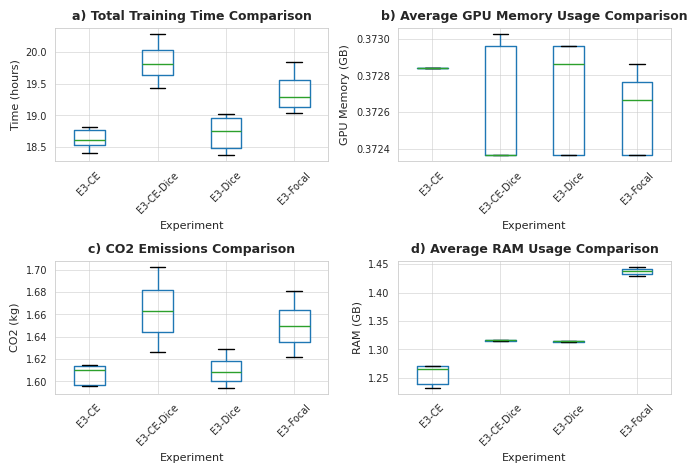

In [14]:
# Visualization for E3
# Create a copy with renamed experiments for display
e3_data_display = e3_data.copy()
e3_data_display['experiment'] = e3_data_display['experiment'].replace({'E2-2.5D': 'E3-CE'})

fig, axes = plt.subplots(2, 2, figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 10/14))

# Training time comparison
ax1 = axes[0, 0]
e3_data_display.boxplot(column='Total Training Time (hours)', by='experiment', ax=ax1, showfliers=False)
ax1.set_title('a) Total Training Time Comparison')
ax1.set_xlabel('Experiment')
ax1.set_ylabel('Time (hours)')
plt.suptitle('')
ax1.tick_params(axis='x', rotation=45)

# GPU Memory comparison
ax2 = axes[0, 1]
e3_data_display.boxplot(column='Average GPU Memory (GB)', by='experiment', ax=ax2, showfliers=False)
ax2.set_title('b) Average GPU Memory Usage Comparison')
ax2.set_xlabel('Experiment')
ax2.set_ylabel('GPU Memory (GB)')
plt.suptitle('')
ax2.tick_params(axis='x', rotation=45)

# CO2 emissions comparison
ax3 = axes[1, 0]
e3_data_display.boxplot(column='CO2 Emissions (kg)', by='experiment', ax=ax3, showfliers=False)
ax3.set_title('c) CO2 Emissions Comparison')
ax3.set_xlabel('Experiment')
ax3.set_ylabel('CO2 (kg)')
plt.suptitle('')
ax3.tick_params(axis='x', rotation=45)

# RAM usage comparison
ax4 = axes[1, 1]
e3_data_display.boxplot(column='Average RAM (GB)', by='experiment', ax=ax4, showfliers=False)
ax4.set_title('d) Average RAM Usage Comparison')
ax4.set_xlabel('Experiment')
ax4.set_ylabel('RAM (GB)')
plt.suptitle('')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig('e3_training_resources')
plt.show()


## 5. Inference Performance Comparison


Inference Summary Statistics:
                Total Inference Time (hours)         Average GPU Memory (GB)  \
                                        mean     std                    mean   
experiment                                                                     
E1-augmentation                       0.6255  0.0120                  0.9638   
E1-no                                 0.6115  0.0128                  0.9638   
E2-2.5D                               0.6728  0.0263                  0.9794   
E2-3D                                 0.0195  0.0002                  0.4718   
E3-CE-Dice                            0.6556     NaN                  0.9794   
E3-Dice                               0.6381     NaN                  0.9794   
E3-Focal                              0.6594     NaN                  0.9794   

                     CO2 Emissions (kg)         Accuracy         Dice Score  \
                 std               mean     std     mean     std       mean   
experiment 

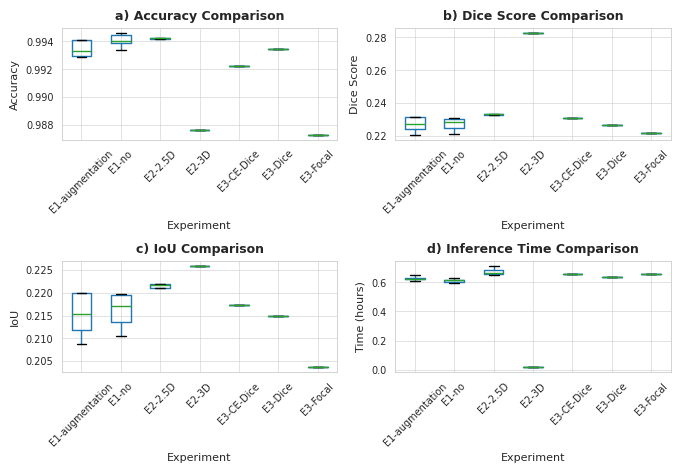

In [15]:
if not all_inference.empty:
    # Summary statistics for inference
    inference_summary = all_inference.groupby('experiment').agg({
        'Total Inference Time (hours)': ['mean', 'std'],
        'Average GPU Memory (GB)': ['mean', 'std'],
        'CO2 Emissions (kg)': ['mean', 'std'],
        'Accuracy': ['mean', 'std'],
        'Dice Score': ['mean', 'std'],
        'IoU': ['mean', 'std']
    }).round(4)
    
    print("Inference Summary Statistics:")
    print(inference_summary)
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 10/14))
    
    # Accuracy comparison
    ax1 = axes[0, 0]
    all_inference.boxplot(column='Accuracy', by='experiment', ax=ax1, showfliers=False)
    ax1.set_title('a) Accuracy Comparison')
    ax1.set_xlabel('Experiment')
    ax1.set_ylabel('Accuracy')
    plt.suptitle('')
    ax1.tick_params(axis='x', rotation=45)
    
    # Dice Score comparison
    ax2 = axes[0, 1]
    all_inference.boxplot(column='Dice Score', by='experiment', ax=ax2, showfliers=False)
    ax2.set_title('b) Dice Score Comparison')
    ax2.set_xlabel('Experiment')
    ax2.set_ylabel('Dice Score')
    plt.suptitle('')
    ax2.tick_params(axis='x', rotation=45)
    
    # IoU comparison
    ax3 = axes[1, 0]
    all_inference.boxplot(column='IoU', by='experiment', ax=ax3, showfliers=False)
    ax3.set_title('c) IoU Comparison')
    ax3.set_xlabel('Experiment')
    ax3.set_ylabel('IoU')
    plt.suptitle('')
    ax3.tick_params(axis='x', rotation=45)
    
    # Inference time comparison
    ax4 = axes[1, 1]
    all_inference.boxplot(column='Total Inference Time (hours)', by='experiment', ax=ax4, showfliers=False)
    ax4.set_title('d) Inference Time Comparison')
    ax4.set_xlabel('Experiment')
    ax4.set_ylabel('Time (hours)')
    plt.suptitle('')
    ax4.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    save_fig('inference_performance')
    plt.show()
else:
    print("Inference data not available")


In [16]:
# Overall summary across all experiments
overall_summary = all_training.groupby('experiment').agg({
    'Total Training Time (hours)': ['mean', 'std', 'count'],
    'Average Epoch Time(s)': ['mean', 'std'],
    'CO2 Emissions (kg)': ['mean', 'sum'],
    'Average RAM (GB)': ['mean'],
    'Average GPU Memory (GB)': ['mean']
}).round(3)

print("Overall Training Summary Across All Experiments:")
print(overall_summary)


Overall Training Summary Across All Experiments:
                Total Training Time (hours)               \
                                       mean    std count   
experiment                                                 
E1-augmentation                      16.354  0.274     5   
E1-no                                15.517  0.756     5   
E2-2.5D                              18.629  0.167     5   
E2-3D                                 5.257  0.124     5   
E3-CE-Dice                           19.842  0.332     5   
E3-Dice                              18.717  0.284     5   
E3-Focal                             19.370  0.328     5   

                Average Epoch Time(s)          CO2 Emissions (kg)         \
                                 mean      std               mean    sum   
experiment                                                                 
E1-augmentation              2943.707   49.388              1.667  8.333   
E1-no                        2793.005  136.158

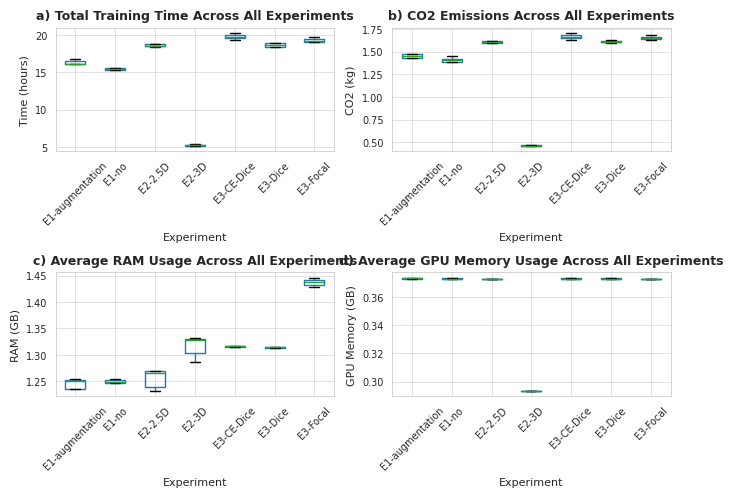

In [17]:
# Create a comprehensive comparison plot
fig, axes = plt.subplots(2, 2, figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 12/16))

# Training time across all experiments
ax1 = axes[0, 0]
all_training.boxplot(column='Total Training Time (hours)', by='experiment', ax=ax1, showfliers=False)
ax1.set_title('a) Total Training Time Across All Experiments', fontsize=9, fontweight='bold')
ax1.set_xlabel('Experiment')
ax1.set_ylabel('Time (hours)')
plt.suptitle('')
ax1.tick_params(axis='x', rotation=45)

# CO2 emissions across all experiments
ax2 = axes[0, 1]
all_training.boxplot(column='CO2 Emissions (kg)', by='experiment', ax=ax2, showfliers=False)
ax2.set_title('b) CO2 Emissions Across All Experiments', fontsize=9, fontweight='bold')
ax2.set_xlabel('Experiment')
ax2.set_ylabel('CO2 (kg)')
plt.suptitle('')
ax2.tick_params(axis='x', rotation=45)

# RAM across all experiments
ax3 = axes[1, 0]
all_training.boxplot(column='Average RAM (GB)', by='experiment', ax=ax3, showfliers=False)
ax3.set_title('c) Average RAM Usage Across All Experiments', fontsize=9, fontweight='bold')
ax3.set_xlabel('Experiment')
ax3.set_ylabel('RAM (GB)')
plt.suptitle('')
ax3.tick_params(axis='x', rotation=45)

# GPU Memory across all experiments
ax4 = axes[1, 1]
all_training.boxplot(column='Average GPU Memory (GB)', by='experiment', ax=ax4, showfliers=False)
ax4.set_title('d) Average GPU Memory Usage Across All Experiments', fontsize=9, fontweight='bold')
ax4.set_xlabel('Experiment')
ax4.set_ylabel('GPU Memory (GB)')
plt.suptitle('')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig('all_experiments_training_resources')
plt.show()


In [18]:
# Calculate key metrics for comparison
comparison_metrics = []

for exp in all_training['experiment'].unique():
    exp_data = all_training[all_training['experiment'] == exp]
    comparison_metrics.append({
        'Experiment': exp,
        'Mean Training Time (hrs)': exp_data['Total Training Time (hours)'].mean(),
        'Mean Epoch Time (s)': exp_data['Average Epoch Time(s)'].mean(),
        'Mean CO2 (kg)': exp_data['CO2 Emissions (kg)'].mean(),
        'Total CO2 (kg)': exp_data['CO2 Emissions (kg)'].sum(),
        'Mean RAM (GB)': exp_data['Average RAM (GB)'].mean(),
        'Mean GPU Memory (GB)': exp_data['Average GPU Memory (GB)'].mean(),
        'Number of Runs': len(exp_data)
    })

comparison_df = pd.DataFrame(comparison_metrics).round(3)
print("\nKey Metrics Comparison Table:")
print(comparison_df.to_string(index=False))



Key Metrics Comparison Table:
     Experiment  Mean Training Time (hrs)  Mean Epoch Time (s)  Mean CO2 (kg)  Total CO2 (kg)  Mean RAM (GB)  Mean GPU Memory (GB)  Number of Runs
          E1-no                    15.517             2793.005          1.393           6.967          1.229                 0.373               5
E1-augmentation                    16.354             2943.707          1.667           8.333          1.245                 0.373               5
        E2-2.5D                    18.629             3353.240          1.606           8.031          1.255                 0.373               5
          E2-3D                     5.257               94.618          0.466           2.329          1.316                 0.294               5
     E3-CE-Dice                    19.842             3571.541          1.663           8.317          1.316                 0.373               5
        E3-Dice                    18.717             3412.306          1.610          

## 7. Key Findings Summary

### E1: Baseline Comparison
- **E1-no**: Baseline model without data augmentation
- **E1-augmentation**: Model with data augmentation
- Compare training efficiency, convergence, and resource usage

### E2: Architecture Comparison  
- **E1-augmentation**: 2D with augmentation (baseline)
- **E2-2.5D**: 2.5D architecture (multi-slice input)
- **E2-3D**: Full 3D architecture
- Compare how different architectures affect training time and resource consumption

### E3: Loss Function Comparison
- **E2-2.5D**: Baseline 2.5D architecture
- **E3-CE-Dice**: Combined Cross-Entropy and Dice loss
- **E3-Dice**: Dice loss only
- **E3-Focal**: Focal loss
- Compare how different loss functions affect training dynamics

### Observations:
1. **Training Time**: Compare total training time and epoch time across experiments
2. **Resource Usage**: Compare RAM and GPU memory consumption
3. **Environmental Impact**: Compare CO2 emissions
4. **Convergence**: Compare convergence epochs where available
5. **Inference Performance**: Compare accuracy, Dice score, and IoU metrics


In [19]:
# Create a summary table with relative improvements
print("\n" + "="*80)
print("SUMMARY OF KEY FINDINGS")
print("="*80)

# E1 Comparison
print("\n[E1] Baseline Comparison:")
e1_no_mean = all_training[all_training['experiment'] == 'E1-no']['Total Training Time (hours)'].mean()
e1_aug_mean = all_training[all_training['experiment'] == 'E1-augmentation']['Total Training Time (hours)'].mean()
time_diff = ((e1_aug_mean - e1_no_mean) / e1_no_mean) * 100
print(f"  Training Time: E1-no = {e1_no_mean:.2f} hrs, E1-augmentation = {e1_aug_mean:.2f} hrs ({time_diff:+.1f}%)")

# E2 Comparison
print("\n[E2] Architecture Comparison:")
e2_25d_mean = all_training[all_training['experiment'] == 'E2-2.5D']['Total Training Time (hours)'].mean()
e2_3d_mean = all_training[all_training['experiment'] == 'E2-3D']['Total Training Time (hours)'].mean()
print(f"  Training Time: E1-augmentation = {e1_aug_mean:.2f} hrs")
print(f"                 E2-2.5D = {e2_25d_mean:.2f} hrs ({((e2_25d_mean - e1_aug_mean) / e1_aug_mean) * 100:+.1f}%)")
print(f"                 E2-3D = {e2_3d_mean:.2f} hrs ({((e2_3d_mean - e1_aug_mean) / e1_aug_mean) * 100:+.1f}%)")

# E3 Comparison
print("\n[E3] Loss Function Comparison:")
e3_ce_dice_mean = all_training[all_training['experiment'] == 'E3-CE-Dice']['Total Training Time (hours)'].mean()
e3_dice_mean = all_training[all_training['experiment'] == 'E3-Dice']['Total Training Time (hours)'].mean()
e3_focal_mean = all_training[all_training['experiment'] == 'E3-Focal']['Total Training Time (hours)'].mean()
print(f"  Training Time: E2-2.5D = {e2_25d_mean:.2f} hrs")
print(f"                 E3-CE-Dice = {e3_ce_dice_mean:.2f} hrs ({((e3_ce_dice_mean - e2_25d_mean) / e2_25d_mean) * 100:+.1f}%)")
print(f"                 E3-Dice = {e3_dice_mean:.2f} hrs ({((e3_dice_mean - e2_25d_mean) / e2_25d_mean) * 100:+.1f}%)")
print(f"                 E3-Focal = {e3_focal_mean:.2f} hrs ({((e3_focal_mean - e2_25d_mean) / e2_25d_mean) * 100:+.1f}%)")

# CO2 Emissions Summary
print("\n[CO2 Emissions Summary]:")
for exp in all_training['experiment'].unique():
    exp_co2 = all_training[all_training['experiment'] == exp]['CO2 Emissions (kg)'].mean()
    print(f"  {exp}: {exp_co2:.3f} kg CO2 per run (mean)")

print("\n" + "="*80)



SUMMARY OF KEY FINDINGS

[E1] Baseline Comparison:
  Training Time: E1-no = 15.52 hrs, E1-augmentation = 16.35 hrs (+5.4%)

[E2] Architecture Comparison:
  Training Time: E1-augmentation = 16.35 hrs
                 E2-2.5D = 18.63 hrs (+13.9%)
                 E2-3D = 5.26 hrs (-67.9%)

[E3] Loss Function Comparison:
  Training Time: E2-2.5D = 18.63 hrs
                 E3-CE-Dice = 19.84 hrs (+6.5%)
                 E3-Dice = 18.72 hrs (+0.5%)
                 E3-Focal = 19.37 hrs (+4.0%)

[CO2 Emissions Summary]:
  E1-no: 1.393 kg CO2 per run (mean)
  E1-augmentation: 1.667 kg CO2 per run (mean)
  E2-2.5D: 1.606 kg CO2 per run (mean)
  E2-3D: 0.466 kg CO2 per run (mean)
  E3-CE-Dice: 1.663 kg CO2 per run (mean)
  E3-Dice: 1.610 kg CO2 per run (mean)
  E3-Focal: 1.650 kg CO2 per run (mean)

